In [1]:
# DATA CLEANING (Using Crop Yield Prediction Dataset)

import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv(r"C:\Users\Alana\Downloads\Crop Yeild Data.csv")

# Display basic information
print(df.head())
print(df.info())

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values in numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill missing values in categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove Production column (Data Leakage)
df.drop("Production", axis=1, inplace=True)

# Check data types
print(df.dtypes)

# Final dataset shape
print("Dataset Shape:", df.shape)

# Save cleaned dataset
df.to_csv("cleaned_crop_yield.csv", index=False)

print("Data Cleaning Completed Successfully")

           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide     Yield  Avg_Temperature  \
0           2051.4  7024878.38   22882.34     0.796           23.692   
1           2051.4   631643.29    2057.47     0.710           23.692   
2           2051.4    75755.32     246.76     0.238           23.692   
3           2051.4  1870661.52    6093.36  5238.052           23.692   
4           2051.4   165500.63     539.09     0.421           23.692   

   Max_Temperature  Min_Temperature  
0           33.435           14.779  
1           33.435           14.779  
2           33.435        

In [2]:
# DATA ANALYSIS (Using Crop Yield Prediction Dataset)

import pandas as pd

df = pd.read_csv(r"C:\Users\Alana\Downloads\Crop Yeild Data.csv")

print("Shape:", df.shape)

print(df.info())

print(df.describe())

print("\nCrop Count")
print(df["Crop"].value_counts())

print("\nState Count")
print(df["State"].value_counts())

print("\nSeason Count")
print(df["Season"].value_counts())

print("\nAverage Yield by Crop")
print(df.groupby("Crop")["Yield"].mean())

print("\nAverage Yield by State")
print(df.groupby("State")["Yield"].mean())

print("\nAverage Yield by Season")
print(df.groupby("Season")["Yield"].mean())

print("\nCorrelation Matrix")
print(df.corr(numeric_only=True))

Shape: (19689, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 2.0+ MB
None
          Crop_Year          Area    Production  Annual_Rainfall  \
count  19689.000000  1.968900e+04  1.968900e+04

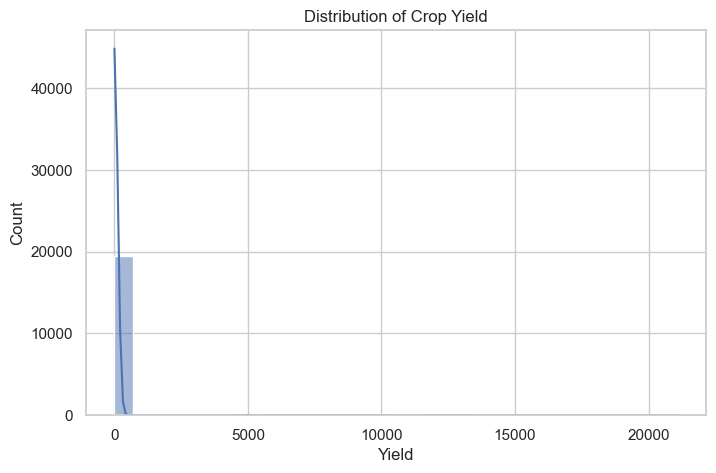

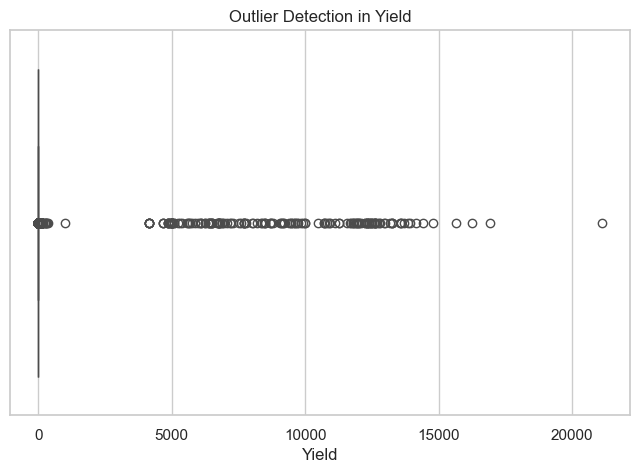

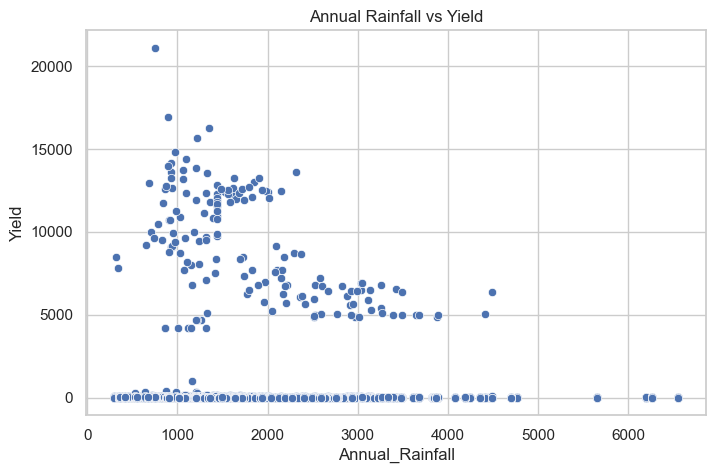

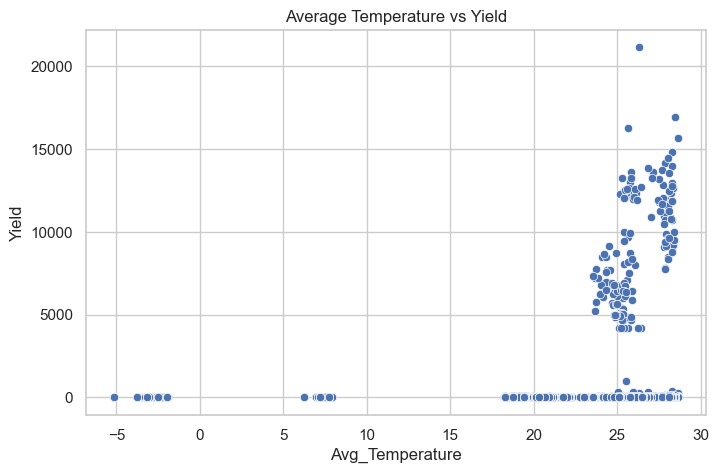

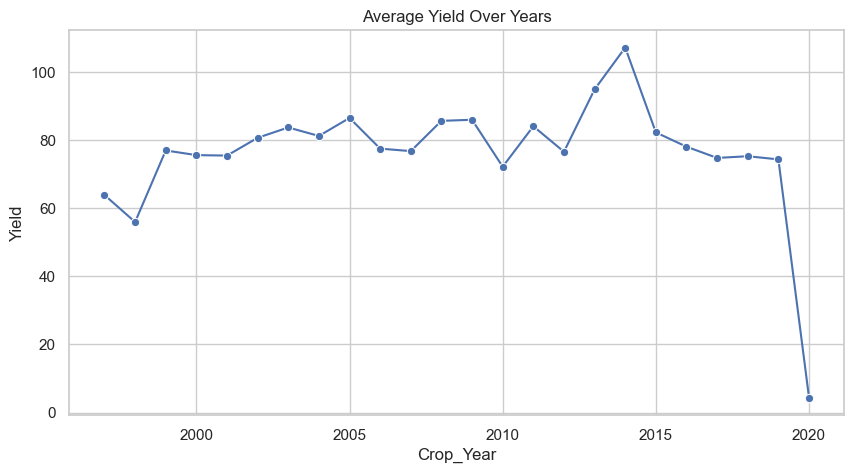

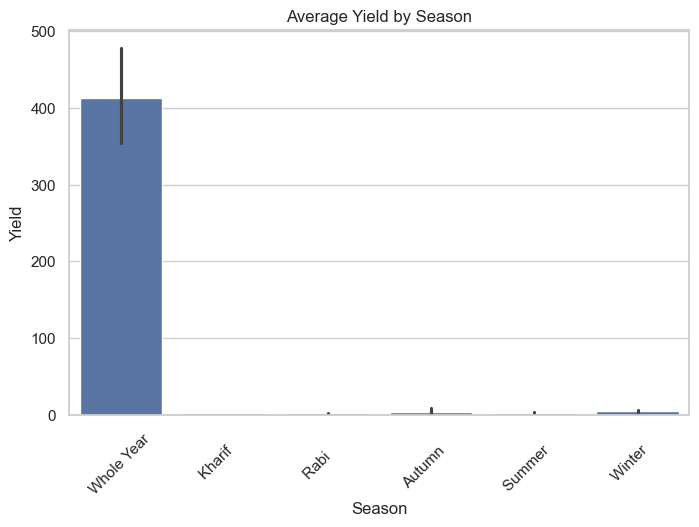

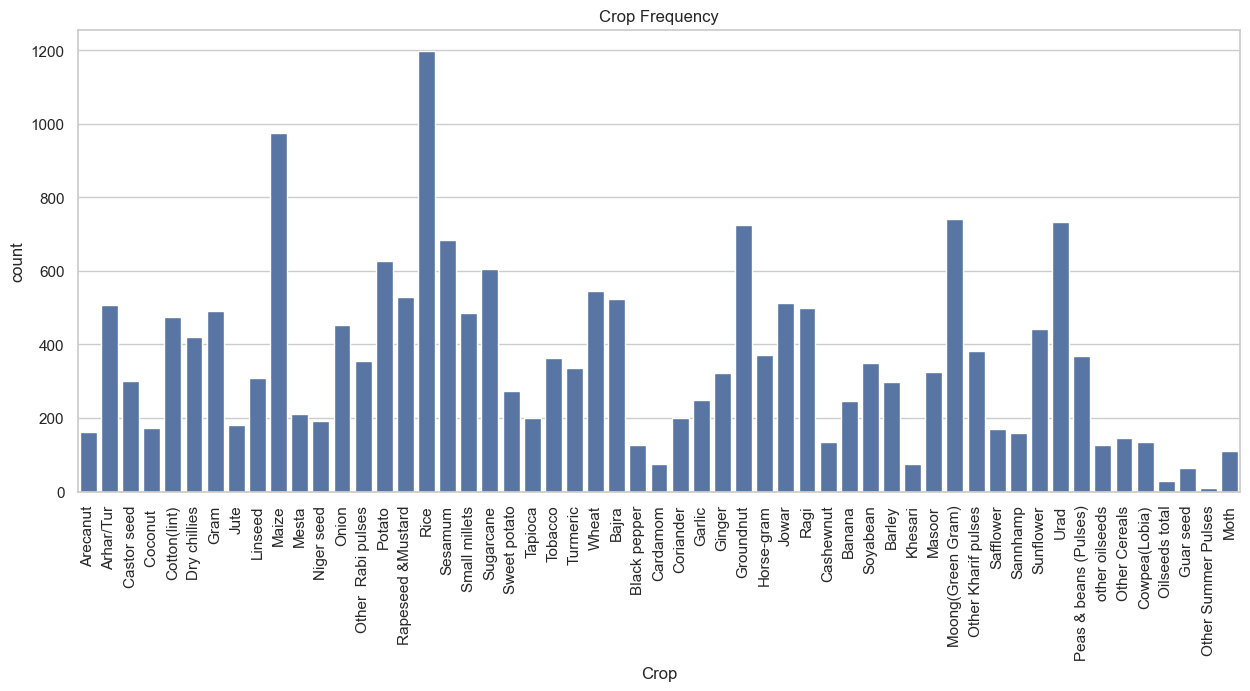

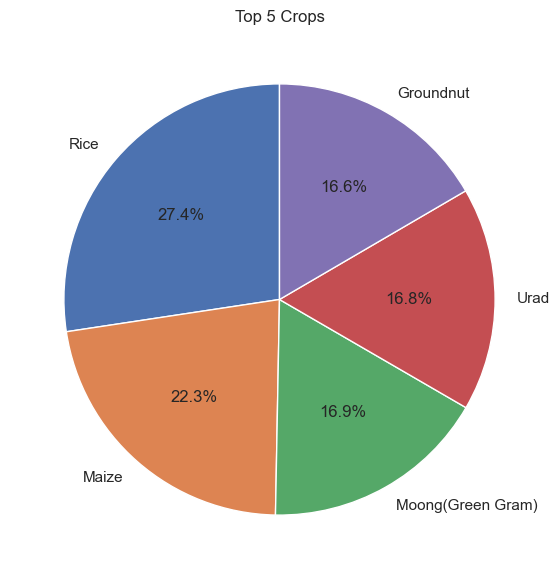

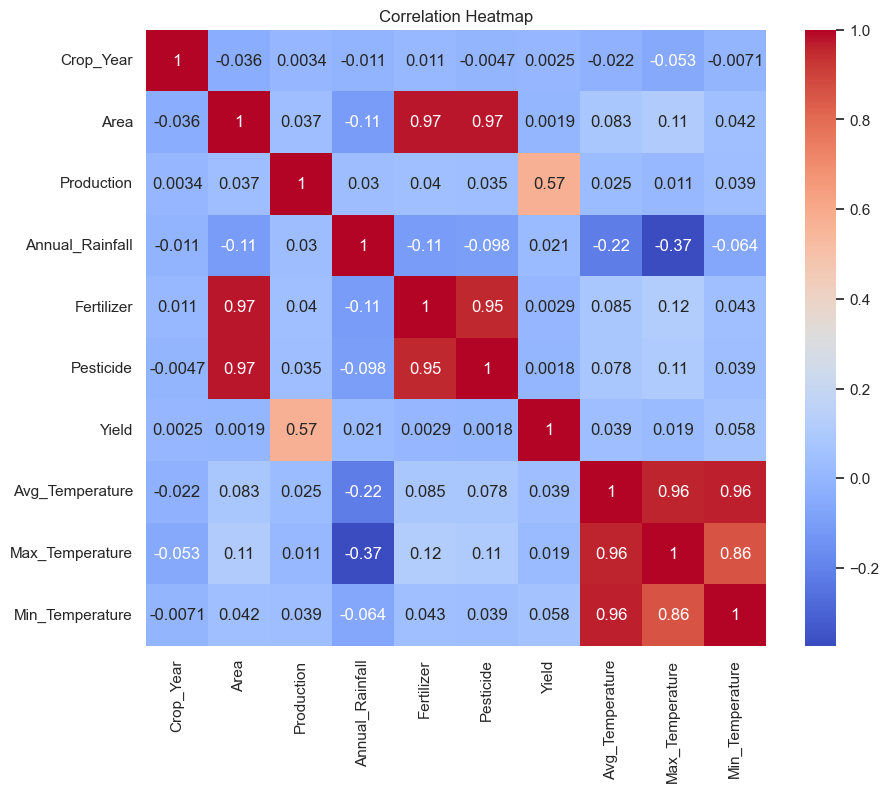

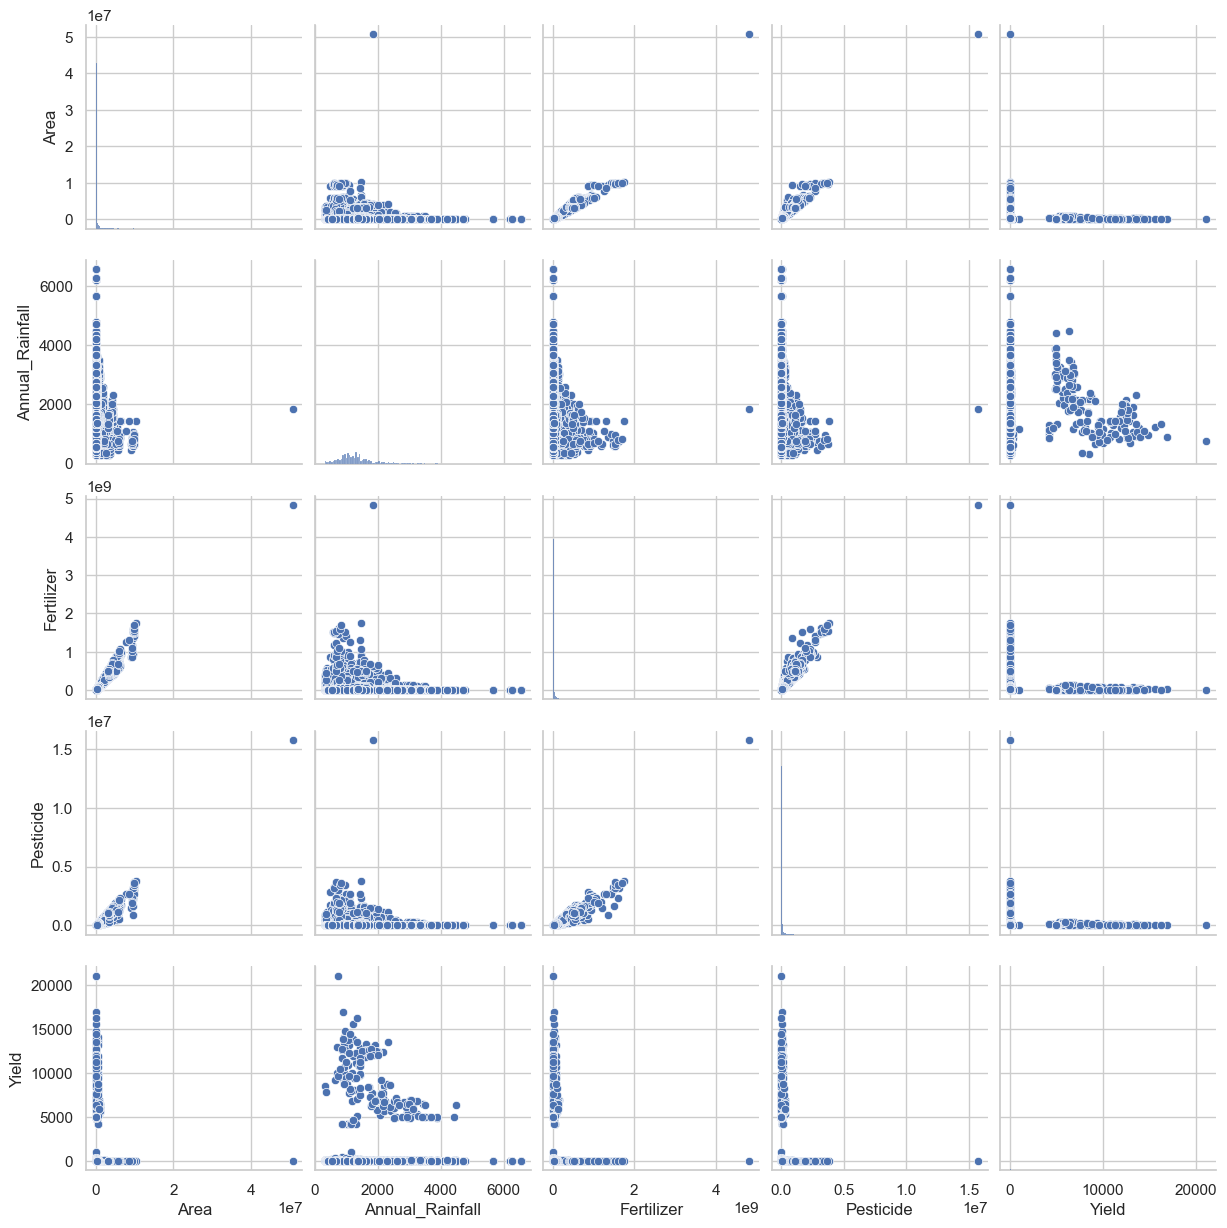

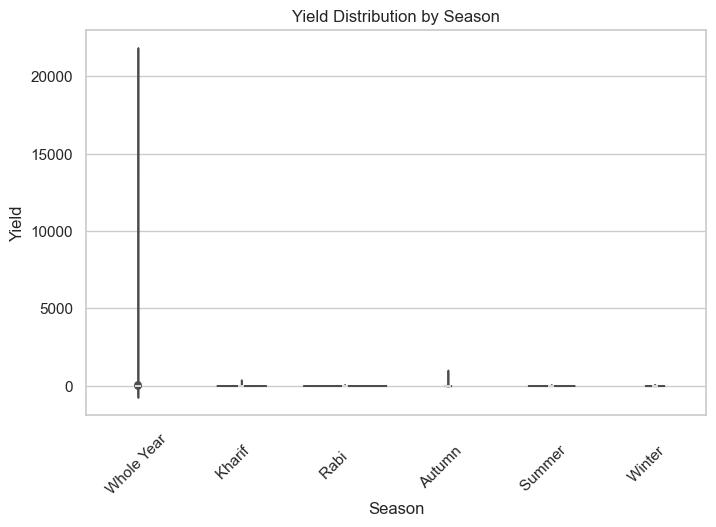

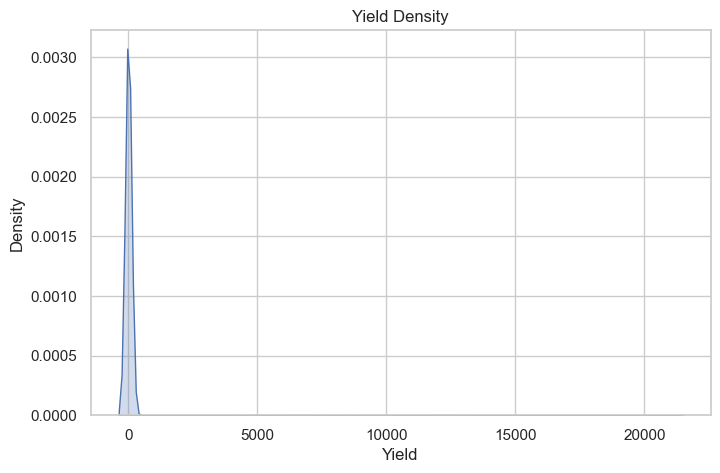

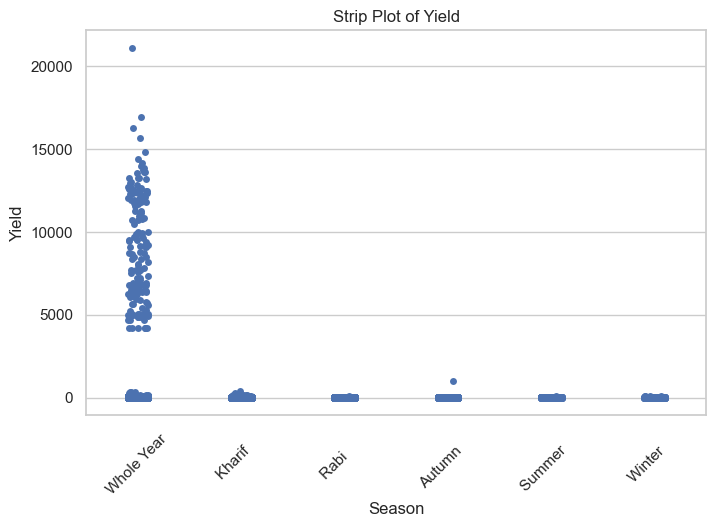

In [ ]:
# VISUALISATION (Using Crop Yield Prediction Dataset)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"C:\Users\Alana\Downloads\Crop Yeild Data.csv")

sns.set(style="whitegrid")

# 1. Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Yield"], bins=30, kde=True)
plt.title("Distribution of Crop Yield")
plt.show()

# 2. Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Yield"])
plt.title("Outlier Detection in Yield")
plt.show()

# 3. Scatter Plot (Rainfall vs Yield)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Annual_Rainfall",
                y="Yield")
plt.title("Annual Rainfall vs Yield")
plt.show()

# 4. Scatter Plot (Temperature vs Yield)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Avg_Temperature",
                y="Yield")
plt.title("Average Temperature vs Yield")
plt.show()

# 5. Line Plot
year_data = df.groupby("Crop_Year")["Yield"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=year_data,
             x="Crop_Year",
             y="Yield",
             marker="o")
plt.title("Average Yield Over Years")
plt.show()

# 6. Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x="Season",
            y="Yield")
plt.xticks(rotation=45)
plt.title("Average Yield by Season")
plt.show()

# 7. Count Plot
plt.figure(figsize=(15,6))
sns.countplot(data=df,
              x="Crop")
plt.xticks(rotation=90)
plt.title("Crop Frequency")
plt.show()

# 8. Pie Chart
top_crop = df["Crop"].value_counts().head(5)

plt.figure(figsize=(7,7))
plt.pie(top_crop,
        labels=top_crop.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Top 5 Crops")
plt.show()

# 9. Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 10. Pair Plot
sns.pairplot(df[["Area",
                 "Annual_Rainfall",
                 "Fertilizer",
                 "Pesticide",
                 "Yield"]])
plt.show()

# 11. Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(data=df,
               x="Season",
               y="Yield")
plt.xticks(rotation=45)
plt.title("Yield Distribution by Season")
plt.show()

# 12. KDE Plot
plt.figure(figsize=(8,5))
sns.kdeplot(df["Yield"],
            fill=True)
plt.title("Yield Density")
plt.show()

# 13. Strip Plot
plt.figure(figsize=(8,5))
sns.stripplot(data=df,
              x="Season",
              y="Yield",
              jitter=True)
plt.xticks(rotation=45)
plt.title("Strip Plot of Yield")
plt.show()

# 14. Swarm Plot
plt.figure(figsize=(8,5))
sns.swarmplot(data=df,
              x="Season",
              y="Yield",
              size=3)
plt.xticks(rotation=45)
plt.title("Swarm Plot")
plt.show()

# 15. Area vs Yield
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Area",
                y="Yield")
plt.title("Area vs Yield")
plt.show()

# 16. Fertilizer vs Yield
plt.figure(figsize=(8,5))
sns.regplot(data=df,
            x="Fertilizer",
            y="Yield")
plt.title("Fertilizer vs Yield")
plt.show()

# 17. Pesticide vs Yield
plt.figure(figsize=(8,5))
sns.regplot(data=df,
            x="Pesticide",
            y="Yield")
plt.title("Pesticide vs Yield")
plt.show()

# 18. Rainfall vs Temperature
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Annual_Rainfall",
                y="Avg_Temperature",
                hue="Season")
plt.title("Rainfall vs Average Temperature")
plt.show()

# 19. Yield by Crop
plt.figure(figsize=(16,6))
sns.boxplot(data=df,
            x="Crop",
            y="Yield")
plt.xticks(rotation=90)
plt.title("Yield Distribution by Crop")
plt.show()

# 20. Yield by State
plt.figure(figsize=(18,6))
sns.boxplot(data=df,
            x="State",
            y="Yield")
plt.xticks(rotation=90)
plt.title("Yield Distribution by State")
plt.show()

print("All Visualizations Completed Successfully")